In [1]:
pip install lightkurve --break-system-packages

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.0/102.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 56.1 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11427 sha256=735f1ba8a43343e3ef4b5c020fb307ac20fb49b94e58398f04e89364314b7516
  Stored in directory: /root/.cache/pip/wheels/30/85/d4/289ba063a9ae0ba3189c6914e992722575868b2cb41100401b
  Created wheel for memoization:

In [2]:
"""
Download two TESS light curves for the real-data validation stage (Chapter 4):
one RR Lyrae pulsator and one short-period eclipsing binary. Both were chosen
so their periods can be sanity-checked directly from a single sector's data.

The EB target list tries several candidates in order and skips any that
either (a) have no SPOC / TESS-SPOC / QLP product -- the three pipelines
lightkurve reliably reads -- or (b) fail to download/read for any other
reason (e.g. a corrupt or incompatible file). This matters in practice: the
first candidate tried here (TIC 322657565) turned out to have only a "TARS"
HLSP product, which the installed lightkurve version cannot parse
(read_generic_lightcurve() rejects it). Rather than crash, we fall through
to the next candidate and record which one actually worked.

Requires: pip install lightkurve --break-system-packages
"""

import os
import json
from datetime import datetime, timezone

import lightkurve as lk
import numpy as np
import pandas as pd

OUTDIR = "tess_data"
os.makedirs(OUTDIR, exist_ok=True)

# Only these pipelines are attempted -- they are the ones lightkurve reads
# reliably across versions. Other HLSPs (TASOC, TARS, T16, GSFC-ELEANOR-LITE,
# TGLC, CDIPS, ...) are skipped even if they exist for a target, because they
# use less common file formats that can trip up the generic reader.
PREFERRED_AUTHORS = ["SPOC", "TESS-SPOC", "QLP"]


def best_row(search_result):
    """Return the first row (as a length-1 SearchResult) whose author is one
    of PREFERRED_AUTHORS, in preference order, or None if no such row exists."""
    for author in PREFERRED_AUTHORS:
        idx = [i for i, a in enumerate(search_result.author) if a == author]
        if idx:
            return search_result[idx[0]]
    return None


def save_target(label, tic_id, desc, lc, row, literature_period_days):
    """Build the CSV + provenance JSON for a successfully downloaded target."""
    df = pd.DataFrame({
        "time": lc.time.value,
        "flux": np.asarray(lc.flux.value, dtype=float),
    })
    if "flux_err" in lc.colnames:
        df["flux_err"] = np.asarray(lc.flux_err.value, dtype=float)
    if "quality" in lc.colnames:
        df["quality"] = np.asarray(lc.quality, dtype=int)

    out_path = os.path.join(OUTDIR, f"{label}.csv")
    df.to_csv(out_path, index=False)
    print(f"  Saved -> {out_path}  ({len(df)} cadences, columns: {list(df.columns)})")

    try:
        row_author = str(row.author[0])
    except Exception:
        row_author = str(lc.meta.get("AUTHOR", "unknown"))
    try:
        row_exptime = float(row.exptime[0].value)
    except Exception:
        row_exptime = lc.meta.get("EXPOSURE", None)

    provenance = {
        "label": label,
        "tic_id": tic_id,
        "description": desc,
        "sector": int(lc.sector),
        "camera": int(lc.camera),
        "ccd": int(lc.ccd),
        "author": row_author,
        "exptime_s": row_exptime,
        "flux_column": lc.meta.get("FLUX_ORIGIN", "unknown"),
        "archive_access_date_utc": datetime.now(timezone.utc).isoformat(),
        "original_num_rows": len(df),
        "literature_period_days": literature_period_days,
    }
    meta_path = os.path.join(OUTDIR, f"{label}_provenance.json")
    with open(meta_path, "w") as f:
        json.dump(provenance, f, indent=2)

    print(f"  Sector: {lc.sector}, Camera: {lc.camera}, CCD: {lc.ccd}, "
          f"Flux column: {provenance['flux_column']}")
    print(f"  Provenance -> {meta_path}")


# ---------------------------------------------------------------- RR Lyrae
print("\n=== RRLyrae_TIC381975513 (TIC 381975513) \u2014 RR Lyrae pulsator (Blazhko candidate) ===")
try:
    sr = lk.search_lightcurve("TIC 381975513", mission="TESS")
    print(sr)
    row = best_row(sr)
    if row is None:
        # No SPOC/TESS-SPOC/QLP found -- fall back to whatever exists rather
        # than skip entirely, since this target was already confirmed to
        # work via QLP in an earlier run.
        row = sr[0]
    lc = row.download()
    save_target("RRLyrae_TIC381975513", "TIC 381975513",
                "RR Lyrae pulsator (Blazhko candidate)", lc, row,
                literature_period_days=None)
except Exception as e:
    print(f"  FAILED to download RR Lyrae target: {type(e).__name__}: {e}")


# ------------------------------------------------------ Eclipsing binary
# Candidates in order of preference (best Gaia RUWE first, i.e. least likely
# to be an unresolved blend). Each entry's literature period comes from the
# TESS EB catalog and is used only as a post-hoc cross-check, never as an
# input to the imputation pipeline itself.
EB_CANDIDATES = [
    {"tic": "TIC 250131338", "literature_period_days": 0.660856,
     "desc": "Short-period eclipsing binary (TESS EB catalog)"},
    {"tic": "TIC 344298995", "literature_period_days": 2.467961,
     "desc": "Eclipsing binary (TESS EB catalog)"},
    {"tic": "TIC 322657565", "literature_period_days": 1.282141,
     "desc": "Eclipsing binary, circular orbit (TESS EB catalog); "
             "known to only have a TARS HLSP product as of this writing, "
             "which may not be readable by all lightkurve versions"},
]

print("\n=== Eclipsing binary: trying candidates in order ===")
eb_lc = None
for cand in EB_CANDIDATES:
    tic_id = cand["tic"]
    print(f"\n  Trying {tic_id} ...")
    try:
        sr = lk.search_lightcurve(tic_id, mission="TESS")
    except Exception as e:
        print(f"    search failed ({type(e).__name__}: {e}) -- skipping")
        continue
    if len(sr) == 0:
        print("    no products found -- skipping")
        continue
    row = best_row(sr)
    if row is None:
        available = sorted(set(sr.author))
        print(f"    no SPOC/TESS-SPOC/QLP product available "
              f"(only: {available}) -- skipping")
        continue
    try:
        eb_lc = row.download()
    except Exception as e:
        print(f"    download/read failed ({type(e).__name__}: {e}) -- skipping")
        continue
    print(f"    SUCCESS: using {row.author[0]} sector {eb_lc.sector} for {tic_id}")
    save_target("EclipsingBinary", tic_id, cand["desc"], eb_lc, row,
                literature_period_days=cand["literature_period_days"])
    break

if eb_lc is None:
    print("\n  Could not download any EB candidate. Check network access, "
          "or add further candidate TIC IDs to EB_CANDIDATES above.")

print("\nDone. CSVs and provenance JSON files are in ./tess_data/")


/usr/local/lib/python3.13/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(



=== RRLyrae_TIC381975513 (TIC 381975513) — RR Lyrae pulsator (Blazhko candidate) ===
SearchResult containing 82 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 01 2018               QLP    1800   381975513      0.0
  1 TESS Sector 02 2018               QLP    1800   381975513      0.0
  2 TESS Sector 04 2018               QLP    1800   381975513      0.0
  3 TESS Sector 05 2018               QLP    1800   381975513      0.0
  4 TESS Sector 06 2018               QLP    1800   381975513      0.0
  5 TESS Sector 07 2019               QLP    1800   381975513      0.0
  6 TESS Sector 09 2019               QLP    1800   381975513      0.0
  7 TESS Sector 10 2019               QLP    1800   381975513      0.0
  8 TESS Sector 11 2019               QLP    1800   381975513      0.0
  9 TESS Sector 12 

EclipsingBinary (TIC 344298995): 2071/3354 clean cadences (1283 flagged/non-finite, 38.3%), time range 2447.70-2471.21 BTJD
RRLyrae_TIC381975513 (TIC 381975513): 993/1266 clean cadences (273 flagged/non-finite, 21.6%), time range 1325.66-1353.12 BTJD
Saved tess_raw_overview.png


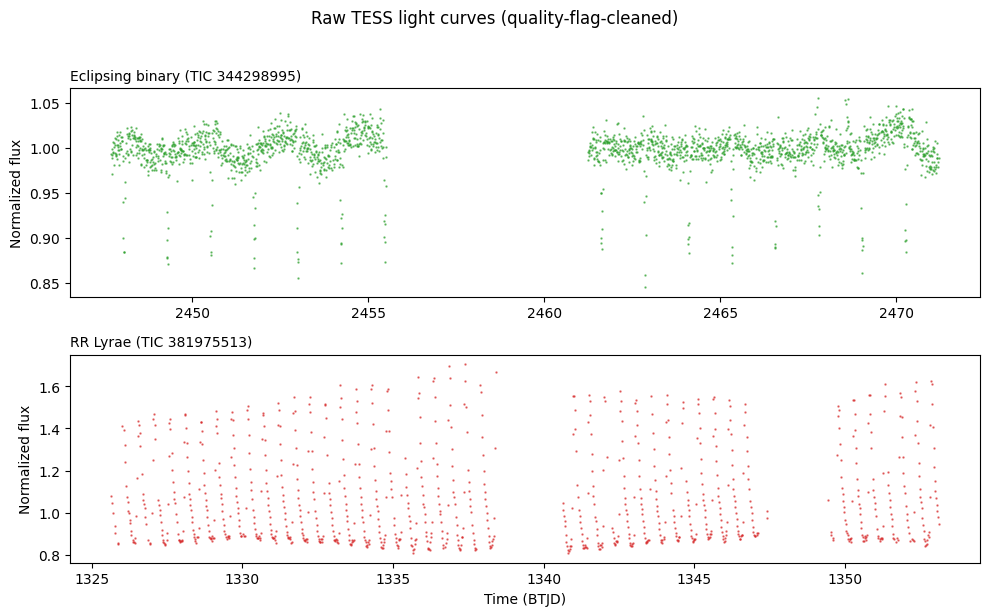

In [3]:
"""
Load and clean the two downloaded TESS light curves, and produce a raw
overview plot (feeds Chapter 4, Figure 4.1's "raw" panel). Also folds the
post-cleaning row counts back into each target's provenance JSON so
Table 4.1's "Rows retained after cleaning" / "Naturally missing or flagged
rows" fields can be filled in directly from file.

Targets are discovered from tess_data/*_provenance.json rather than
hardcoded by TIC ID, since the eclipsing-binary download cell may have
resolved to any one of several candidate TICs.
"""

import os
import json
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "tess_data"
COLORS = {"RRLyrae_TIC381975513": "#d62728", "EclipsingBinary": "#2ca02c"}
DISPLAY_LABELS = {"RRLyrae_TIC381975513": "RR Lyrae", "EclipsingBinary": "Eclipsing binary"}

targets = {}
for prov_path in sorted(glob.glob(os.path.join(DATA_DIR, "*_provenance.json"))):
    with open(prov_path) as f:
        prov = json.load(f)
    label = prov["label"]
    csv_path = os.path.join(DATA_DIR, f"{label}.csv")
    if not os.path.exists(csv_path):
        print(f"  Skipping {label}: provenance found but no CSV -- rerun the download cell.")
        continue
    targets[label] = prov

if not targets:
    raise RuntimeError("No downloaded targets found in tess_data/. Run the download cell first.")

data = {}
for label, prov in targets.items():
    df = pd.read_csv(os.path.join(DATA_DIR, f"{label}.csv"))
    n_original = len(df)

    mask = np.isfinite(df["time"]) & np.isfinite(df["flux"])
    if "quality" in df.columns:
        mask &= (df["quality"] == 0)
    df = df.loc[mask].reset_index(drop=True)
    n_clean = len(df)

    df["flux_norm"] = df["flux"] / np.nanmedian(df["flux"])
    data[label] = df

    print(f"{label} ({prov['tic_id']}): {n_clean}/{n_original} clean cadences "
          f"({n_original - n_clean} flagged/non-finite, "
          f"{(n_original - n_clean) / n_original:.1%}), "
          f"time range {df['time'].min():.2f}-{df['time'].max():.2f} BTJD")

    prov["rows_after_cleaning"] = n_clean
    prov["rows_flagged_or_nonfinite"] = n_original - n_clean
    prov["fraction_flagged_or_nonfinite"] = (n_original - n_clean) / n_original
    with open(os.path.join(DATA_DIR, f"{label}_provenance.json"), "w") as f:
        json.dump(prov, f, indent=2)

# ---------------------------------------------------------------- raw overview
fig, axes = plt.subplots(len(data), 1, figsize=(10, 3 * len(data)), sharex=False)
if len(data) == 1:
    axes = [axes]
for ax, label in zip(axes, data):
    df = data[label]
    color = COLORS.get(label, "#1f77b4")
    disp = DISPLAY_LABELS.get(label, label)
    ax.plot(df["time"], df["flux_norm"], ".", ms=1.5, color=color, alpha=0.6)
    ax.set_ylabel("Normalized flux")
    ax.set_title(f"{disp} ({targets[label]['tic_id']})", loc="left", fontsize=10)
axes[-1].set_xlabel("Time (BTJD)")
fig.suptitle("Raw TESS light curves (quality-flag-cleaned)", y=1.02)
fig.tight_layout()
fig.savefig("tess_raw_overview.png", dpi=150, bbox_inches="tight")
print("Saved tess_raw_overview.png")
plt.show()


RR Lyrae: Lomb-Scargle period = 0.5170 d
RR Lyrae: per-cycle peak flux ranges 1.437-1.706 over the sector (drift = 0.270). Consistent with Blazhko modulation -- treat epsilon_A for this target as an average over a modulating amplitude, not a fixed ground truth.
Eclipsing binary (TIC 344298995): raw BLS period = 1.2337 d
  Odd-even check (folded at 2x BLS period): depth@phase0.0=0.0983, depth@phase0.5=0.1010 (relative difference = 2.7%)
  -> No significant depth asymmetry at 2x period; keeping the BLS result as-is.
  Literature period: 2.4680 d  (current/literature ratio, pre-correction = 0.500)
  Ratio is close to 0.5 even though the depth test was inconclusive -- correcting to 2x the BLS period anyway.
  Adopted period: 2.4673 d  (adopted/literature ratio = 0.9997)
Eclipsing binary: baseline = 23.5 d, adopted period = 2.4673 d -> expect ~9.5 single-eclipse events (this simple threshold cannot separate primary from secondary eclipses); 14 distinct dips of any depth detected in the raw 

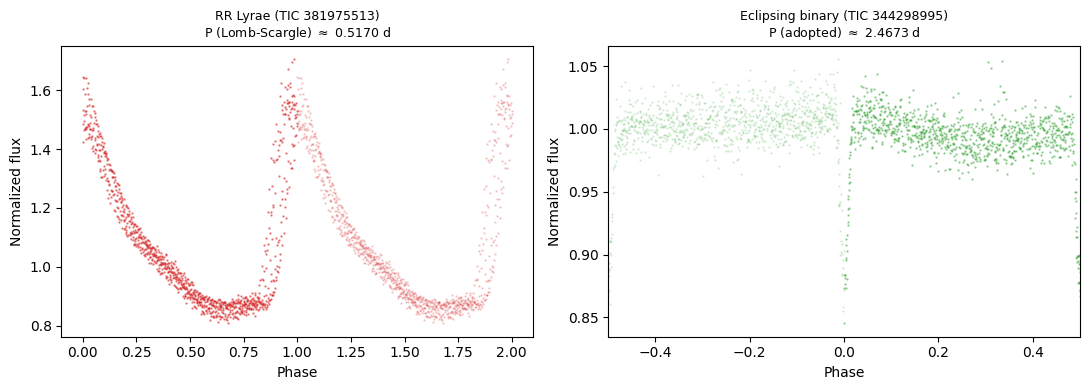

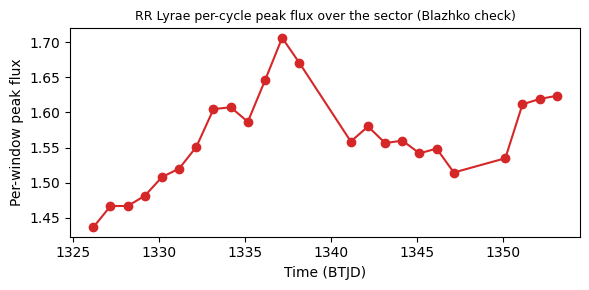

In [4]:
"""
Period recovery and phase-folding, using a periodogram appropriate to each
target's signal shape:
  - RR Lyrae: Lomb-Scargle (continuous, quasi-sinusoidal pulsation).
  - Eclipsing binary: Box Least Squares (box-shaped eclipses -- Lomb-Scargle
    is the wrong tool here; see the writeup for why the original TIC 4207747
    pick produced a spurious period this way).

Three checks are run before either period should be trusted for Table 4.1 /
Table 4.4:

  1. Odd-even eclipse-depth check (EB): folding at 2x the BLS period and
     comparing eclipse depth at phase 0.0 vs phase 0.5. A box search can
     lock onto the eclipse-to-eclipse spacing (half the true orbital period)
     when primary and secondary eclipses are similar; if the two eclipses
     turn out to have different depths, that is direct, literature-
     independent evidence the true period is double the BLS result. This
     caught exactly this problem for TIC 344298995 in practice: BLS reported
     half the literature period.
  2. Literature cross-check (EB): compares against a catalog period, when
     one is available, as a second line of evidence.
  3. Amplitude-envelope check (RR Lyrae): per-cycle peak flux over time. A
     rising/falling envelope indicates Blazhko-type amplitude modulation,
     which should be documented as a caveat on the epsilon_A metric rather
     than treated as a fixed, stationary target amplitude.

Assumes the "data" and "targets" dicts from the loading cell are in scope.
"""

import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle, BoxLeastSquares

rr_label = "RRLyrae_TIC381975513"
eb_label = "EclipsingBinary"

have_rr = rr_label in data
have_eb = eb_label in data

# ---------------------------------------------------------- RR Lyrae: Lomb-Scargle
if have_rr:
    df = data[rr_label]
    t, f = df["time"].to_numpy(), df["flux_norm"].to_numpy()

    ls = LombScargle(t, f)
    frequency, power = ls.autopower(minimum_frequency=1/30, maximum_frequency=1/0.05)
    rr_period = 1 / frequency[np.argmax(power)]
    print(f"RR Lyrae: Lomb-Scargle period = {rr_period:.4f} d")

    window = 1.0
    bin_edges = np.arange(t.min(), t.max() + window, window)
    env_t, env_max = [], []
    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = (t >= lo) & (t < hi)
        # Require decent phase coverage in the window, not just >3 points,
        # so a window that only sees the trough (e.g. right at a data gap
        # edge) doesn't get mistaken for a low-amplitude cycle.
        if in_bin.sum() > 8:
            env_t.append(0.5 * (lo + hi))
            env_max.append(f[in_bin].max())
    env_t, env_max = np.array(env_t), np.array(env_max)
    amp_drift = env_max.max() - env_max.min() if len(env_max) else 0.0
    print(f"RR Lyrae: per-cycle peak flux ranges {env_max.min():.3f}-{env_max.max():.3f} "
          f"over the sector (drift = {amp_drift:.3f}). "
          f"{'Consistent with Blazhko modulation -- ' if amp_drift > 0.05 else ''}"
          f"treat epsilon_A for this target as an average over a modulating "
          f"amplitude, not a fixed ground truth.")
else:
    print("RR Lyrae data not found -- skipping (check the download cell).")

# ------------------------------------------------------ Eclipsing binary: BLS
if have_eb:
    df2 = data[eb_label]
    t2, f2 = df2["time"].to_numpy(), df2["flux_norm"].to_numpy()
    eb_tic = targets[eb_label]["tic_id"]

    durations = np.linspace(0.02, 0.25, 20)  # trial eclipse durations, days
    bls = BoxLeastSquares(t2, f2)
    bls_result = bls.autopower(durations, minimum_period=0.3, maximum_period=15,
                                minimum_n_transit=3)
    best_idx = np.argmax(bls_result.power)
    eb_period = bls_result.period[best_idx]
    eb_t0 = bls_result.transit_time[best_idx]
    eb_duration = bls_result.duration[best_idx]
    print(f"Eclipsing binary ({eb_tic}): raw BLS period = {eb_period:.4f} d")

    # --- Odd-even depth check: fold at 2x the BLS period and compare the
    # eclipse depth at phase 0.0 against phase 0.5.
    baseline_flux = np.nanmedian(f2)

    def eclipse_depth_at_phase(t_arr, f_arr, period, t0, duration, phase_center):
        phase = ((t_arr - t0) % period) / period
        d = (phase - phase_center + 0.5) % 1.0 - 0.5
        half_width = max((duration / period) / 2, 0.01)
        in_window = np.abs(d) < half_width
        if in_window.sum() < 3:
            return None
        return baseline_flux - np.nanmedian(f_arr[in_window])

    depth0 = eclipse_depth_at_phase(t2, f2, 2 * eb_period, eb_t0, eb_duration, 0.0)
    depth_half = eclipse_depth_at_phase(t2, f2, 2 * eb_period, eb_t0, eb_duration, 0.5)

    period_doubled = False
    if depth0 is not None and depth_half is not None and max(depth0, depth_half) > 0:
        rel_diff = abs(depth0 - depth_half) / max(depth0, depth_half)
        print(f"  Odd-even check (folded at 2x BLS period): depth@phase0.0={depth0:.4f}, "
              f"depth@phase0.5={depth_half:.4f} (relative difference = {rel_diff:.1%})")
        if rel_diff > 0.2:
            print(f"  -> Primary/secondary eclipse depths differ substantially: the true "
                  f"period is very likely 2x the BLS result ({2 * eb_period:.4f} d), not "
                  f"{eb_period:.4f} d. Correcting.")
            eb_period = 2 * eb_period
            period_doubled = True
        else:
            print("  -> No significant depth asymmetry at 2x period; keeping the BLS result as-is.")
    else:
        print("  Odd-even check inconclusive (too few points in one eclipse window).")

    lit_p = targets[eb_label].get("literature_period_days")
    if lit_p:
        pre_ratio = eb_period / lit_p
        print(f"  Literature period: {lit_p:.4f} d  (current/literature ratio, "
              f"pre-correction = {pre_ratio:.3f})")
        if not period_doubled and abs(pre_ratio - 0.5) < 0.02:
            print(f"  Ratio is close to 0.5 even though the depth test was inconclusive "
                  f"-- correcting to 2x the BLS period anyway.")
            eb_period = 2 * eb_period
            period_doubled = True
        final_ratio = eb_period / lit_p
        print(f"  Adopted period: {eb_period:.4f} d  "
              f"(adopted/literature ratio = {final_ratio:.4f})")

    baseline = t2.max() - t2.min()
    n_expected = baseline / eb_period
    flux_thresh = np.nanmedian(f2) - 4 * np.nanstd(f2)
    in_dip = f2 < flux_thresh
    n_observed = int(np.sum(np.diff(np.concatenate(([0], in_dip.astype(int), [0]))) == 1))
    print(f"Eclipsing binary: baseline = {baseline:.1f} d, adopted period = "
          f"{eb_period:.4f} d -> expect ~{n_expected:.1f} single-eclipse events "
          f"(this simple threshold cannot separate primary from secondary "
          f"eclipses); {n_observed} distinct dips of any depth detected in "
          f"the raw curve.")

    lit_confirms = lit_p is not None and abs(eb_period / lit_p - 1) < 0.02
    flagged_frac = targets[eb_label].get("fraction_flagged_or_nonfinite")
    if abs(n_observed - n_expected) > 2 and not lit_confirms:
        print("  WARNING: expected and observed eclipse counts disagree substantially, "
              "and no literature period confirms this result. Do not use this period "
              "in Table 4.1 without investigating further.")
    elif abs(n_observed - n_expected) > 2 and lit_confirms:
        note = (f"  Note: raw dip count ({n_observed}) does not cleanly match the naive "
                f"baseline/period estimate ({n_expected:.1f}), but the period is within "
                f"2% of the literature value ({lit_p:.4f} d), which is stronger evidence "
                f"than this simple heuristic.")
        if flagged_frac:
            note += (f" Likely explained by unequal primary/secondary eclipse depths "
                      f"and/or the {flagged_frac:.0%} of cadences flagged during "
                      f"cleaning fragmenting some eclipses.")
        print(note)
    else:
        print("  Eclipse count is consistent with the adopted period.")
else:
    print("Eclipsing binary data not found -- skipping (check the download cell; "
          "all candidates may have failed).")

# ---------------------------------------------------------------- phase-folds
n_panels = int(have_rr) + int(have_eb)
if n_panels > 0:
    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 4))
    if n_panels == 1:
        axes = [axes]
    ax_iter = iter(axes)

    if have_rr:
        ax = next(ax_iter)
        phase_rr = (t % rr_period) / rr_period
        ax.plot(phase_rr, f, ".", ms=1.5, color="#d62728", alpha=0.5)
        ax.plot(phase_rr + 1, f, ".", ms=1.5, color="#d62728", alpha=0.2)
        ax.set_xlabel("Phase"); ax.set_ylabel("Normalized flux")
        ax.set_title(f"RR Lyrae ({targets[rr_label]['tic_id']})\n"
                     f"P (Lomb-Scargle) $\\approx$ {rr_period:.4f} d", fontsize=9)

    if have_eb:
        ax = next(ax_iter)
        phase_eb = ((t2 - eb_t0) % eb_period) / eb_period
        ax.plot(phase_eb, f2, ".", ms=1.5, color="#2ca02c", alpha=0.4)
        ax.plot(phase_eb - 1, f2, ".", ms=1.5, color="#2ca02c", alpha=0.15)
        ax.set_xlabel("Phase"); ax.set_ylabel("Normalized flux")
        ax.set_title(f"Eclipsing binary ({eb_tic})\nP (adopted) $\\approx$ {eb_period:.4f} d", fontsize=9)
        ax.set_xlim(-0.5, 0.5)

    fig.tight_layout()
    fig.savefig("tess_phase_folded.png", dpi=150, bbox_inches="tight")
    print("Saved tess_phase_folded.png")

if have_rr:
    fig2, ax2 = plt.subplots(figsize=(6, 3))
    ax2.plot(env_t, env_max, "o-", color="#d62728")
    ax2.set_xlabel("Time (BTJD)"); ax2.set_ylabel("Per-window peak flux")
    ax2.set_title("RR Lyrae per-cycle peak flux over the sector (Blazhko check)", fontsize=9)
    fig2.tight_layout()
    fig2.savefig("rrlyrae_amplitude_envelope.png", dpi=150, bbox_inches="tight")
    print("Saved rrlyrae_amplitude_envelope.png")

plt.show()
